<div style="background:linear-gradient(135deg,#01172F 0%,#123B62 68%,#D9A441 140%);padding:30px;border-radius:18px;color:white;margin:8px 0 24px 0;box-shadow:0 8px 24px #01172F22">
  <div style="font-size:12px;letter-spacing:1.8px;font-weight:700;color:#E8C87E">LIA · ENTREGA 1.1 · 01 DE 03</div>
  <h1 style="margin:10px 0 8px 0;font-size:34px;line-height:1.16;color:white">Titanic: calibrando uma análise confiável</h1>
  <p style="font-size:17px;line-height:1.55;margin:0 0 16px 0;color:#E8EEF5">Antes de confiar nos resultados, verificamos as regras que produzem esses resultados.</p>
  <span style="display:inline-block;background:#FFFFFF22;border:1px solid #FFFFFF55;padding:5px 10px;border-radius:999px;margin:3px 4px 0 0;font-size:12px">NumPy</span> <span style="display:inline-block;background:#FFFFFF22;border:1px solid #FFFFFF55;padding:5px 10px;border-radius:999px;margin:3px 4px 0 0;font-size:12px">Pandas</span> <span style="display:inline-block;background:#FFFFFF22;border:1px solid #FFFFFF55;padding:5px 10px;border-radius:999px;margin:3px 4px 0 0;font-size:12px">Qualidade de dados</span>
</div>

| 📦 Dataset | 📄 Arquivo | 📐 Dimensões | 🎯 Papel |
|---|---|---:|---|
| Titanic (espelho seaborn-data) | `titanic.csv` | **891 × 15** | Calibração do pipeline |

> **Saída deste notebook:** `resultados/entrega_1_1.json`

## ⚡ Em 30 segundos

- A imputação pela média reduz a dispersão de `age` em **10,49%**.
- Duas convenções de quantil encontram **4** ou **1** outlier na mesma amostra.
- A correlação muda de **−0,1176** no agregado para positiva em todas as espécies do Iris.

## 🗺️ Roteiro do notebook

| | Etapa | O que acontece |
|---:|---|---|
| 🔍 | **Auditar** | integridade, ausências, duplicatas e vazamento |
| 🧹 | **Preparar** | limpar e transformar sem apagar evidências |
| 🧪 | **Testar** | imputação, quantis e paradoxo de Simpson |
| 💾 | **Registrar** | salvar achados para a síntese final |

> ▶️ **Como usar:** execute as células de cima para baixo. A primeira célula monta o Drive, confere os arquivos e prepara o ambiente.

---

## 🎯 1. Escopo

### 1.1 Questão de pesquisa

> As convenções estatísticas do pipeline produzem os valores corretos, e quais decisões de pré-processamento alteram conclusões sem gerar erro?

### 1.2 Papel na Entrega 1

O Titanic não é objeto de estudo nesta entrega. É instrumento de verificação:
pequeno, canônico e com valores publicados, permite confirmar que o pipeline
calcula o que se espera antes de aplicá-lo a dados desconhecidos.

Um erro de convenção detectado aqui custa segundos. O mesmo erro detectado na
Entrega 1.3, sobre 123 mil linhas, custa a revisão de toda a análise.

### 1.3 Pré-requisitos de execução

- Python 3.10+ com `numpy`, `pandas`, `matplotlib`, `seaborn`, `scipy`
- `nucleo.py` e `titanic.csv` no diretório apontado por `DADOS`
- Nenhuma entrega anterior — esta é a primeira da sequência


---

## 🧭 2. Matriz de rastreabilidade

Mapa rápido entre o desafio, a seção e a evidência gerada.

| Requisito | Seção | Evidência produzida |
|---|---|---|
| Limpeza dos dados | 5 e 6 | duplicatas, ausentes, padronização textual, colunas derivadas |
| Análise exploratória | 5, 7 e 10 | perfil, agregações múltiplas, cruzamentos |
| Visualizações informativas | 7, 8, 9 e 10 | distribuição, comparação, tendência, correlação |
| Identificação de insights | 7, 8, 9 e 10 | três modos de falha e uma interação quantificados |
| Conclusões e recomendações | 12 | cinco recomendações operacionais |


---

## 📐 3. Convenções e premissas

### 3.1 Convenções estatísticas

Fixadas em `nucleo.CONVENCOES` e idênticas nas três entregas. A célula de
calibração da Seção 4 interrompe a execução se qualquer uma divergir.

| Convenção | Valor adotado | Alternativa comum | Efeito da troca |
|---|---|---|---|
| Quantil | interpolação linear (tipo 7 de Hyndman–Fan) | tipo 1 (sem interpolação) | altera contagem de outliers |
| Desvio padrão | `ddof=1` (amostral) | `ddof=0` (populacional, padrão do NumPy) | altera dispersão reportada |
| Outlier | regra de Tukey, `1,5 × IQR` | `3σ` | altera critério de exclusão |
| Correlação | Pearson | Spearman | altera sensibilidade a não-linearidade |

### 3.2 Premissas declaradas

**P1. Fonte do dataset** — utilizado o espelho `seaborn-data`, não o `train.csv` da competição Kaggle. Os esquemas divergem (`survived`/`Survived`, `class`/`Pclass`) e a calibração é específica desta versão.

**P2. Ausência de imputação nos dados analisados** — nenhuma imputação é aplicada ao conjunto de trabalho. A Seção 7 cria uma cópia isolada apenas para medir o efeito da imputação.

**P3. Escopo das conclusões** — entrega metodológica. Nenhuma conclusão histórica sobre o naufrágio é reivindicada: o dataset contém 891 registros de aproximadamente 2.224 pessoas a bordo, com amostragem não aleatória.

**P4. Tratamento de string vazia** — `''` é tratado como ausência semântica distinta de `NaN`. A Seção 5.2 quantifica ambos separadamente.



---

## ⚙️ 4. Preparação do ambiente

In [1]:
# @title ⚙️ Preparar ambiente e conferir arquivos
import importlib.util
import json
import math
import os
import subprocess
import sys
import urllib.request
from pathlib import Path

# Caminho principal no Google Drive. No Colab, você pode editar pelo formulário.
PASTA_PROJETO = "/content/drive/MyDrive/Entrega1"  # @param {"type":"string"}
try:
    EM_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    EM_COLAB = False

if EM_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    DADOS = Path(PASTA_PROJETO)
else:
    DADOS = Path.cwd()

if not DADOS.exists():
    raise FileNotFoundError(
        f"Pasta não encontrada: {DADOS}\n"
        "Crie MyDrive/Entrega1, envie o pacote e execute esta célula novamente."
    )

os.chdir(DADOS)
sys.path.insert(0, str(DADOS))
Path("resultados").mkdir(exist_ok=True)

# Arquivos didáticos pequenos: baixa somente se ainda não estiverem na pasta.
DOWNLOADS = {
    "titanic.csv": "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv",
    "iris.csv": "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv",
}
for nome, url in DOWNLOADS.items():
    if not Path(nome).exists():
        print(f"⬇️ Baixando {nome}...")
        urllib.request.urlretrieve(url, nome)

# Instala apenas o que estiver ausente no ambiente atual.
PACOTES = {
    "numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib",
    "seaborn": "seaborn", "scipy": "scipy", "pyarrow": "pyarrow",
}
faltam_pacotes = [pacote for modulo, pacote in PACOTES.items()
                   if importlib.util.find_spec(modulo) is None]
if faltam_pacotes:
    print("📦 Instalando:", ", ".join(faltam_pacotes))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *faltam_pacotes])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats

import nucleo as nu

nu.aplicar_estilo()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)

ITENS = {
    "nucleo.py": "módulo compartilhado",
    "titanic.csv": "calibração",
    "iris.csv": "teste de quantis e correlação",
    "d2.csv": "IoT Security & Energy",
    "d3.csv": "RT-IoT2022",
    "resultados/entrega_1_1.json": "resultado da etapa 1.1",
    "resultados/entrega_1_2.json": "resultado da etapa 1.2",
}
painel = pd.DataFrame([
    {"status": "✅ OK" if Path(arquivo).exists() else "⬜ pendente",
      "arquivo": arquivo, "papel": papel}
    for arquivo, papel in ITENS.items()
])
display(painel)

obrigatorios = ['nucleo.py', 'titanic.csv', 'iris.csv']
faltando = [arquivo for arquivo in obrigatorios if not Path(arquivo).exists()]
if faltando:
    raise FileNotFoundError(
        "Arquivos necessários para esta etapa:\n- " + "\n- ".join(faltando)
    )

print(f"✅ Ambiente pronto · {DADOS}")
print("📐 Convenções:", nu.CONVENCOES)

Mounted at /content/drive


,status,arquivo,papel
0,✅ OK,nucleo.py,módulo compartilhado
1,✅ OK,titanic.csv,calibração
2,✅ OK,iris.csv,teste de quantis e correlação
3,✅ OK,d2.csv,IoT Security & Energy
4,✅ OK,d3.csv,RT-IoT2022
5,⬜ pendente,resultados/entrega_1_1.json,resultado da etapa 1.1
6,⬜ pendente,resultados/entrega_1_2.json,resultado da etapa 1.2


✅ Ambiente pronto · /content/drive/MyDrive/Entrega1
📐 Convenções: {'quantil': 'linear', 'ddof': 1, 'outlier': '1.5*IQR', 'corr': 'pearson'}


A calibração abaixo é a primeira barreira de qualidade
da entrega. Recalcula seis agregados do Titanic e compara com valores conhecidos.
Divergência interrompe a execução — não emite aviso.

In [2]:
# @title ▶️ ⚙️ 4. Preparação do ambiente
# Regressão de convenções. Verifica 6 grupos do Titanic contra valores
# conhecidos. Interrompe a execução se qualquer convenção tiver mudado.
assert nu.calibrar("titanic.csv"), "convenções divergiram — investigar antes de prosseguir"

calibracao: OK -- 6/6 grupos, age nulos=177 | convencoes={'quantil': 'linear', 'ddof': 1, 'outlier': '1.5*IQR', 'corr': 'pearson'}


---

## 🔍 5. Auditoria de entrada

Primeiro, conferimos o arquivo; depois, interpretamos os dados.

### 5.1 Integridade do arquivo

> 🎯 **Pergunta:** Confirmar que o parser leu o arquivo integralmente e registrar sua identidade.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Comparação entre a contagem bruta de linhas — independente do parser — e o número de registros produzido pelo `pandas`. Divergência indica quebra de linha dentro de campo, codificação incorreta ou aspas mal balanceadas. O md5 identifica a versão exata do arquivo analisado.

</details>

In [3]:
# @title ▶️ 5.1 Integridade do arquivo
df = nu.carregar("titanic.csv",
                categoricas=("sex", "class", "embarked", "who", "alive"))

integridade = nu.integridade("titanic.csv", df)
print("Integridade:", integridade)
print(f"Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas")
df.head()

Integridade: {'md5': '56f29cc0b807', 'linhas_wc': 891, 'linhas_parser': 891, 'confere': True}
Dimensões: 891 linhas × 15 colunas


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,None,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,None,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,None,Southampton,no,True


> ✅ **Leitura principal**
>
> Contagem íntegra: 891 linhas por ambos os métodos. O md5 registrado
> identifica a versão do arquivo e é replicado no JSON de saída, permitindo que uma
> reexecução futura confirme que analisou o mesmo dado.

### 5.2 Perfil por coluna

> 🎯 **Pergunta:** Quantificar ausências, cardinalidade e colunas sem variância.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

`nucleo.perfil` separa três condições frequentemente confundidas: `NaN` (ausência reconhecida pelo parser), string vazia (ausência semântica invisível a `isnull`) e coluna constante (presente mas sem informação).

</details>

In [4]:
# @title ▶️ 5.2 Perfil por coluna
perfil = nu.perfil(df)
perfil

,coluna,dtype,nulos,nulos_%,vazios_str,unicos,constante
11,deck,object,688,77.22,0,7,False
3,age,float64,177,19.87,0,88,False
7,embarked,category,2,0.22,0,3,False
12,embark_town,object,2,0.22,0,3,False
2,sex,category,0,0.00,0,2,False
1,pclass,int64,0,0.00,0,3,False
0,survived,int64,0,0.00,0,2,False
6,fare,float64,0,0.00,0,248,False
5,parch,int64,0,0.00,0,7,False
4,sibsp,int64,0,0.00,0,7,False


> ✅ **Leitura principal**
>
> `deck` apresenta 77,22% de ausências — inutilizável para análise
> e descartada na Seção 6. `age` apresenta 19,87%, tratada na Seção 7. `embarked` e
> `embark_town` compartilham as mesmas duas ausências, indicando redundância.

A coluna `vazios_str` existe porque `isnull()` **não detecta string vazia**. Um
registro com campo textual em branco atravessa qualquer verificação de nulos. No
material de referência da disciplina, essa condição exigiu uma linha de limpeza
separada precisamente por não ser capturada pelo teste de nulos.

### 5.3 Duplicatas

> 🎯 **Pergunta:** Verificar se há registros repetidos, integralmente ou em subconjunto de colunas.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Duas verificações: duplicatas de linha inteira e duplicatas nas colunas que deveriam identificar unicamente um passageiro. Além da contagem, caracteriza-se o perfil dos registros duplicados — a decisão de remover ou manter depende de eles representarem repetição de registro ou coincidência legítima de atributos.

</details>

In [5]:
# @title ▶️ 5.3 Duplicatas
dup_total = int(df.duplicated().sum())
chave = ["sex", "age", "fare", "class", "embarked"]
dup_chave = int(df.duplicated(subset=chave).sum())

print(f"Duplicatas de linha inteira: {dup_total}")
print(f"Duplicatas na chave {chave}: {dup_chave}")

envolvidos = df[df.duplicated(keep=False)]
print(f"Linhas envolvidas em duplicata total: {len(envolvidos)}")
print(f"   com idade ausente: {envolvidos['age'].isna().sum()} "
      f"({envolvidos['age'].isna().mean():.1%})")
print("   distribuição por classe:")
print(envolvidos["class"].value_counts().to_string())
print()
print("Exemplo de grupo repetido:")
display(envolvidos.sort_values(list(df.columns), na_position="last")
        .head(6)[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]])

Duplicatas de linha inteira: 107
Duplicatas na chave ['sex', 'age', 'fare', 'class', 'embarked']: 137
Linhas envolvidas em duplicata total: 160
   com idade ausente: 93 (58.1%)
   distribuição por classe:
class
Third     125
Second     31
First       4

Exemplo de grupo repetido:


,survived,pclass,sex,age,sibsp,parch,fare,embarked
64,0,1,male,NaN,0,0,27.7208,C
295,0,1,male,NaN,0,0,27.7208,C
144,0,2,male,18.0,0,0,11.5000,S
757,0,2,male,18.0,0,0,11.5000,S
658,0,2,male,23.0,0,0,13.0000,S
733,0,2,male,23.0,0,0,13.0000,S


> ✅ **Leitura principal**
>
> Há **107 duplicatas de linha inteira**, envolvendo 160 registros.
> O material de referência prevê `drop_duplicates` como etapa padrão de limpeza. Aqui, essa
> remoção seria **incorreta**.

O perfil dos registros duplicados explica o porquê: **125 dos 160 pertencem à terceira
classe** e **58,1% têm idade ausente**. São passageiros distintos que coincidem em todos
os quinze atributos observados — mesmo sexo, mesma tarifa, mesmo porto, viajando
sozinhos, com idade não registrada. A coincidência é consequência da baixa
dimensionalidade efetiva do registro, não de duplicação.

**Duplicata de atributos não é duplicata de entidade** quando a chave não é
identificadora. Este dataset não possui identificador de passageiro; aplicar
`drop_duplicates` eliminaria 107 pessoas reais e reduziria artificialmente a
representação da terceira classe — precisamente o grupo de menor sobrevivência.

Decisão adotada: **manter as duplicatas**, registrando-as. A justificativa consta do
Apêndice A.

### 5.4 Vazamento de alvo

> 🎯 **Pergunta:** Localizar colunas que determinam a variável de interesse por derivação, e não por predição.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Para cada coluna categórica de cardinalidade tratável, calcula-se a pureza do alvo dentro de cada nível. Pureza mínima acima de 0,99 sinaliza que a coluna reproduz o alvo. O procedimento é automático porque inspeção visual de nomes de coluna não escala — a Entrega 1.3 possui 85.

</details>

In [6]:
# @title ▶️ 5.4 Vazamento de alvo
suspeitos = nu.suspeitos_de_vazamento(df, "survived")
print("Colunas sinalizadas:", suspeitos)
pd.crosstab(df["alive"], df["survived"], margins=True)

Colunas sinalizadas: ['alive']


survived,0,1,All
alive,,,
no,549,0,549
yes,0,342,342
All,549,342,891


> ✅ **Leitura principal**
>
> `alive` é `survived` codificado como texto. A tabela cruzada é
> perfeitamente diagonal: correlação unitária.

Em análise descritiva a coluna é inofensiva. Em modelagem, produz acurácia de 100%
sem capacidade preditiva. O mesmo padrão reaparece na Entrega 1.2, onde `LABEL`
duplica `ATTACK`.

---

## 🧹 6. Limpeza e transformação

As transformações são feitas em uma cópia; o conjunto original permanece intacto.

### 6.1 Descarte, padronização textual e derivação

> 🎯 **Pergunta:** Produzir um conjunto de trabalho limpo, com transformações rastreáveis.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Quatro operações em sequência: descarte de coluna com ausência majoritária; padronização de capitalização em campo textual; criação de coluna derivada por faixa, com `pd.cut`; criação de coluna derivada por condição, com `np.where`. As bordas do `pd.cut` são declaradas explicitamente porque o parâmetro `right=True` (padrão) produz intervalos semiabertos à esquerda — um valor igual à borda inferior do primeiro intervalo é descartado silenciosamente.

</details>

In [7]:
# @title ▶️ 6.1 Descarte, padronização textual e derivação
trab = df.drop(columns=["deck"]).copy()          # 77,22% ausente

trab["embark_town"] = trab["embark_town"].astype(str).str.strip().str.title()

# Borda inferior -0.01 para INCLUIR idade 0: com bins=[0, ...] e right=True o
# primeiro intervalo seria (0, 12] e idades fracionárias abaixo de 1 cairiam fora.
BORDAS = [-0.01, 12, 25, 60, 120]
ROTULOS = ["0–12", "13–25", "26–60", "61+"]
trab["faixa_etaria"] = pd.cut(trab["age"], bins=BORDAS, labels=ROTULOS)

trab["acompanhado"] = np.where(trab["sibsp"] + trab["parch"] > 0, "Sim", "Não")

perdidas = int(trab["age"].notna().sum() - trab["faixa_etaria"].notna().sum())
print(f"Colunas: {df.shape[1]} → {trab.shape[1]}")
print(f"Idades observadas descartadas pelas bordas: {perdidas}")
print(f"\nDistribuição de faixa_etaria (NaN = idade ausente):")
print(trab["faixa_etaria"].value_counts(dropna=False).to_string())
trab[["age", "faixa_etaria", "sibsp", "parch", "acompanhado", "embark_town"]].head()

Colunas: 15 → 16
Idades observadas descartadas pelas bordas: 0

Distribuição de faixa_etaria (NaN = idade ausente):
faixa_etaria
26–60    391
13–25    232
NaN      177
0–12      69
61+       22


,age,faixa_etaria,sibsp,parch,acompanhado,embark_town
0,22.0,13–25,1,0,Sim,Southampton
1,38.0,26–60,1,0,Sim,Cherbourg
2,26.0,26–60,0,0,Não,Southampton
3,35.0,26–60,1,0,Sim,Southampton
4,35.0,26–60,0,0,Não,Southampton


> ✅ **Leitura principal**
>
> Nenhuma idade observada é perdida pelas bordas — a escolha de
> `-0.01` como limite inferior preserva os passageiros com idade fracionária abaixo de
> um ano, que seriam descartados por `bins=[0, ...]`.

Os 177 `NaN` em `faixa_etaria` correspondem exatamente às idades ausentes e são
**preservados como ausentes**, não redistribuídos. A Seção 7 demonstra por que
imputá-los antes da análise comprometeria a leitura.

---

## ⚠️ 7. Modo de falha I — imputação anterior à análise

O material de referência preenche `age` com a média e, em seguida, analisa a distribuição de `age`. Esta seção quantifica o efeito.

### 7.1 Efeito da imputação pela média sobre a dispersão

> 🎯 **Pergunta:** Medir a contração de variância induzida por imputação com a média e confrontar o valor observado com a previsão teórica.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Compara-se o desvio padrão amostral antes e depois da imputação, verificando se a razão observada coincide com o fator analítico.

**📐 Critério técnico**

Seja $X$ com $m$ valores observados de $n$ totais e $\bar{x}$ a média dos
observados. Após imputar os $n-m$ ausentes com $\bar{x}$, cada termo imputado
contribui $(\bar{x} - \bar{x})^2 = 0$ à soma dos quadrados:

$$s^2_{\text{imp}} = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2
= \frac{m-1}{n-1}\, s^2_{\text{obs}}
\quad\Longrightarrow\quad
\frac{s_{\text{imp}}}{s_{\text{obs}}} = \sqrt{\frac{m-1}{n-1}}$$

A média permanece inalterada; a dispersão contrai por um fator conhecido.

</details>

In [8]:
# @title ▶️ 7.1 Efeito da imputação pela média sobre a dispersão
bruta = df["age"]
imputada = bruta.fillna(bruta.mean())

n, m = len(bruta), int(bruta.notna().sum())
fator_teorico = np.sqrt((m - 1) / (n - 1))
razao_obs = nu.desvio(imputada) / nu.desvio(bruta)

print(f"n (total)................: {n}")
print(f"m (observados)...........: {m}   ({bruta.isna().sum()} ausentes = {bruta.isna().mean():.2%})")
print(f"média....................: {bruta.mean():.4f}  →  {imputada.mean():.4f}")
print(f"desvio (ddof=1)..........: {nu.desvio(bruta):.4f}  →  {nu.desvio(imputada):.4f}")
print(f"razão observada..........: {razao_obs:.9f}")
print(f"fator teórico √((m-1)/(n-1)): {fator_teorico:.9f}")
print(f"concordância.............: {'CONFIRMADA' if abs(razao_obs - fator_teorico) < 1e-9 else 'DIVERGENTE'}")
print(f"contração da dispersão...: {1 - razao_obs:.2%}")

n (total)................: 891
m (observados)...........: 714   (177 ausentes = 19.87%)
média....................: 29.6991  →  29.6991
desvio (ddof=1)..........: 14.5265  →  13.0020
razão observada..........: 0.895055080
fator teórico √((m-1)/(n-1)): 0.895055080
concordância.............: CONFIRMADA
contração da dispersão...: 10.49%


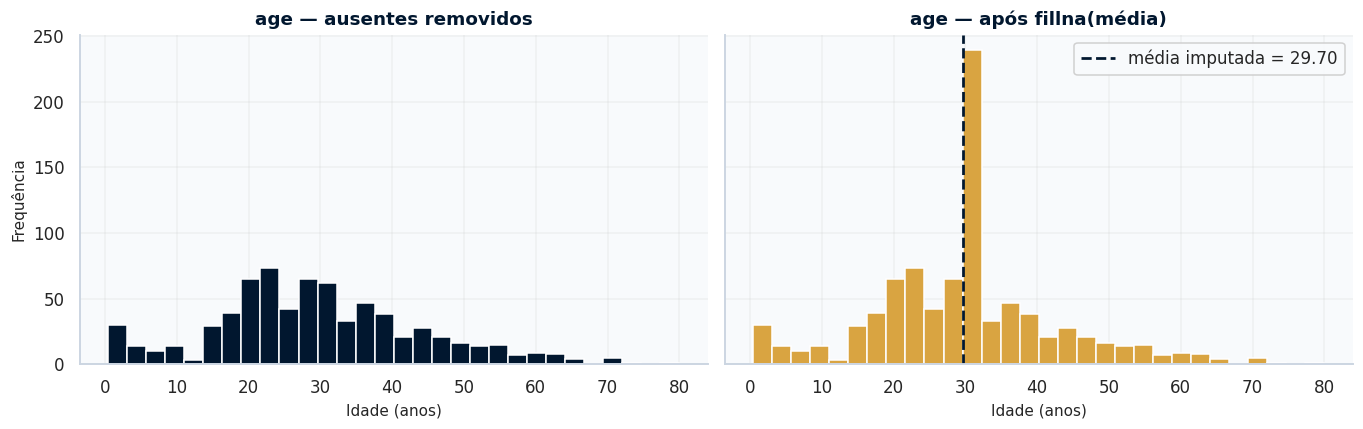

In [9]:
# @title ▶️ 7.1 Efeito da imputação pela média sobre a dispersão
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4), sharey=True)

ax[0].hist(bruta.dropna(), bins=30, color=nu.PALETA["navy"], edgecolor="white")
ax[0].set_title("age — ausentes removidos")
ax[0].set_xlabel("Idade (anos)"); ax[0].set_ylabel("Frequência")

ax[1].hist(imputada, bins=30, color=nu.PALETA["gold"], edgecolor="white")
ax[1].axvline(bruta.mean(), color=nu.PALETA["navy"], ls="--", lw=1.8,
              label=f"média imputada = {bruta.mean():.2f}")
ax[1].set_title("age — após fillna(média)")
ax[1].set_xlabel("Idade (anos)"); ax[1].legend()

plt.tight_layout(); plt.show()

> ✅ **Leitura principal**
>
> A razão observada coincide com o fator teórico até a nona casa
> decimal, confirmando a derivação. A dispersão contrai **10,49%**.

O pico visível no segundo histograma não existe na população: são 177 observações
concentradas em um único valor. Qualquer histograma, diagrama de violino ou faixa
etária construído sobre essa coluna herda o artefato, e a contração da dispersão
**atenua** qualquer associação medida entre idade e sobrevivência.

Agravante específico deste dataset: a ausência de idade não é aleatória — concentra-se
na terceira classe. Imputar a média global insere o valor central justamente no grupo
de menor sobrevivência, enviesando a comparação entre classes.

**Recomendação:** marcar a imputação em coluna auxiliar booleana, ou não imputar em
variável cuja distribuição será analisada. As duas operações na mesma coluna, sem
marcação, produzem análise sobre artefato.

---

## ⚠️ 8. Modo de falha II — convenção de quantil

Não existe definição única de quantil amostral. A taxonomia de Hyndman e Fan cataloga nove. Esta seção mede o efeito da escolha sobre a detecção de outliers.

### 8.1 Duas definições, mesma amostra

> 🎯 **Pergunta:** Quantificar a divergência entre a definição adotada por `numpy`/`pandas` e a implementação direta mais comum.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Aplicam-se as duas definições ao cálculo de quartis do Iris, e delas deriva-se a contagem de outliers pela regra de Tukey. O Iris é usado por ser o exemplo de diagrama de caixa do material de referência.

**📐 Critério técnico**

Para $n$ observações ordenadas $x_{(1)} \le \cdots \le x_{(n)}$ e quantil $q$:

**Tipo 7** (interpolação linear — adotado por `numpy` e `pandas`):
$$h = (n-1)q, \qquad Q_7(q) = x_{(\lfloor h \rfloor + 1)} + \bigl(h - \lfloor h \rfloor\bigr)\Bigl(x_{(\lceil h \rceil + 1)} - x_{(\lfloor h \rfloor + 1)}\Bigr)$$

**Tipo 1** (sem interpolação — implementação direta usual):
$$Q_1(q) = x_{(\lceil nq \rceil)}$$

Regra de Tukey: $x$ é outlier se $x < Q_1 - 1{,}5\,\text{IQR}$ ou $x > Q_3 + 1{,}5\,\text{IQR}$.

</details>

In [10]:
# @title ▶️ 8.1 Duas definições, mesma amostra
iris = pd.read_csv("iris.csv")

def q_tipo7(o, q):
    h = (len(o) - 1) * q
    lo, hi = math.floor(h), math.ceil(h)
    return o[lo] + (h - lo) * (o[hi] - o[lo])

def q_tipo1(o, q):
    return o[max(math.ceil(q * len(o)) - 1, 0)]

reg = []
for esp in iris["species"].unique():
    o = sorted(iris[iris["species"] == esp]["petal_length"])
    for nome, fn in (("tipo 7", q_tipo7), ("tipo 1", q_tipo1)):
        q1, q3 = fn(o, .25), fn(o, .75)
        iqr = q3 - q1
        reg.append({"espécie": esp, "definição": nome, "Q1": q1, "Q3": q3,
                    "IQR": round(iqr, 4),
                    "lim. inferior": round(q1 - 1.5*iqr, 4),
                    "lim. superior": round(q3 + 1.5*iqr, 4),
                    "outliers": sum(1 for v in o if v < q1-1.5*iqr or v > q3+1.5*iqr)})

quantis = pd.DataFrame(reg)
quantis

,espécie,definição,Q1,Q3,IQR,lim. inferior,lim. superior,outliers
0,setosa,tipo 7,1.4,1.575,0.175,1.1375,1.8375,4
1,setosa,tipo 1,1.4,1.600,0.200,1.1000,1.9000,1
2,versicolor,tipo 7,4.0,4.600,0.600,3.1000,5.5000,1
3,versicolor,tipo 1,4.0,4.600,0.600,3.1000,5.5000,1
4,virginica,tipo 7,5.1,5.875,0.775,3.9375,7.0375,0
5,virginica,tipo 1,5.1,5.900,0.800,3.9000,7.1000,0


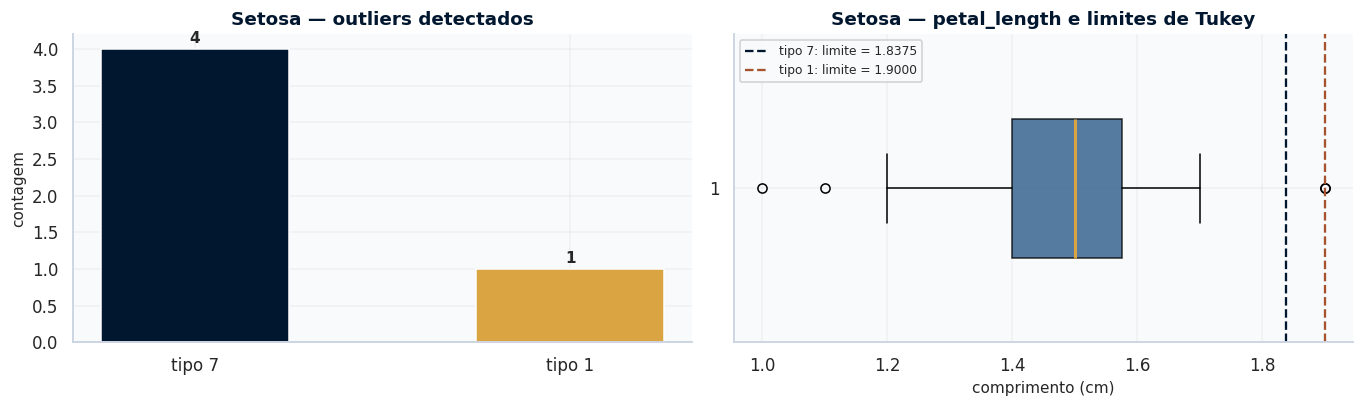

In [11]:
# @title ▶️ 8.1 Duas definições, mesma amostra
setosa = quantis[quantis["espécie"] == "setosa"]
o_set = sorted(iris[iris["species"] == "setosa"]["petal_length"])

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))

ax[0].bar(setosa["definição"], setosa["outliers"],
          color=[nu.PALETA["navy"], nu.PALETA["gold"]], width=.5)
ax[0].set_title("Setosa — outliers detectados"); ax[0].set_ylabel("contagem")
for i, v in enumerate(setosa["outliers"]):
    ax[0].text(i, v + .08, str(v), ha="center", fontweight="bold")

ax[1].boxplot(o_set, vert=False, widths=.45, patch_artist=True,
              boxprops={"facecolor": nu.PALETA["steel"], "alpha": .8},
              medianprops={"color": nu.PALETA["gold"], "linewidth": 2})
for _, r in setosa.iterrows():
    cor = nu.PALETA["navy"] if r["definição"] == "tipo 7" else nu.PALETA["rust"]
    ax[1].axvline(r["lim. superior"], color=cor, ls="--", lw=1.5,
                  label=f'{r["definição"]}: limite = {r["lim. superior"]:.4f}')
ax[1].set_title("Setosa — petal_length e limites de Tukey")
ax[1].set_xlabel("comprimento (cm)"); ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

> ✅ **Leitura principal**
>
> **Setosa: 4 outliers pela definição tipo 7, 1 pela tipo 1.**
> Mesma amostra, nenhum erro de execução, nenhum aviso.

O mecanismo é visível no gráfico à direita: o IQR passa de 0,175 para 0,200, e como o
limite é $Q_3 + 1{,}5\,\text{IQR}$, uma diferença de 0,025 no IQR desloca o limite em
0,0375 — deslocamento suficiente para reclassificar três observações.

Este resultado justifica a existência de `nucleo.CONVENCOES`. Uma entrega que não
declara a definição de quantil utilizada não é reprodutível, ainda que o código esteja
integralmente disponível.

---

## ⚠️ 9. Modo de falha III — agregação sobre grupos heterogêneos

### 9.1 Paradoxo de Simpson

> 🎯 **Pergunta:** Verificar se a correlação calculada no conjunto agregado preserva o sinal da correlação calculada dentro de cada grupo.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Calcula-se a correlação de Pearson entre `sepal_length` e `sepal_width` no conjunto completo do Iris e, separadamente, dentro de cada espécie.

**📐 Critério técnico**

A correlação agregada mistura variação *entre* grupos e variação *dentro* de
grupos. A covariância total decompõe-se em

$$\text{Cov}(X,Y) = \underbrace{\mathbb{E}\bigl[\text{Cov}(X,Y \mid G)\bigr]}_{\text{dentro}}
+ \underbrace{\text{Cov}\bigl(\mathbb{E}[X\mid G],\ \mathbb{E}[Y\mid G]\bigr)}_{\text{entre}}$$

e o segundo termo pode dominar e inverter o sinal do primeiro.

</details>

In [12]:
# @title ▶️ 9.1 Paradoxo de Simpson
pooled = iris["sepal_length"].corr(iris["sepal_width"])
por_especie = iris.groupby("species")[["sepal_length", "sepal_width"]].corr().iloc[0::2, 1]

print(f"Correlação agregada (3 espécies): {pooled:+.4f}")
print("\nCorrelação por espécie:")
print(por_especie.round(4).to_string())

Correlação agregada (3 espécies): -0.1176

Correlação por espécie:
species                 
setosa      sepal_length    0.7425
versicolor  sepal_length    0.5259
virginica   sepal_length    0.4572


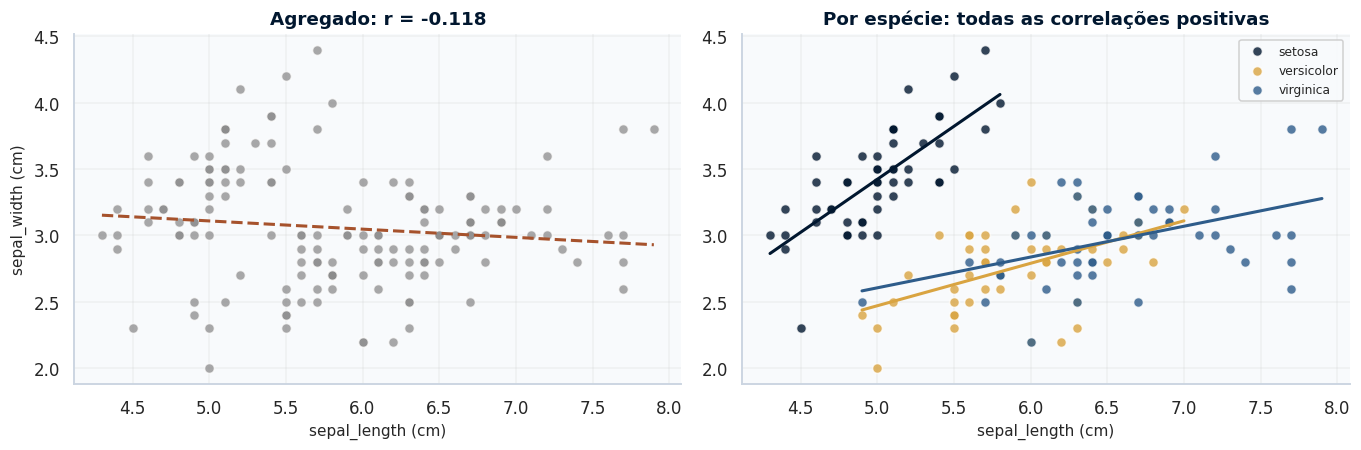

In [13]:
# @title ▶️ 9.1 Paradoxo de Simpson
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))

ax[0].scatter(iris["sepal_length"], iris["sepal_width"],
              color=nu.PALETA["cinza"], alpha=.75, edgecolors="white", s=42)
z = np.polyfit(iris["sepal_length"], iris["sepal_width"], 1)
xs = np.linspace(iris["sepal_length"].min(), iris["sepal_length"].max(), 50)
ax[0].plot(xs, np.poly1d(z)(xs), color=nu.PALETA["rust"], ls="--", lw=2)
ax[0].set_title(f"Agregado: r = {pooled:+.3f}")
ax[0].set_xlabel("sepal_length (cm)"); ax[0].set_ylabel("sepal_width (cm)")

for (esp, sub), cor in zip(iris.groupby("species"), nu.SEQ):
    ax[1].scatter(sub["sepal_length"], sub["sepal_width"], label=esp,
                  color=cor, alpha=.8, edgecolors="white", s=42)
    z = np.polyfit(sub["sepal_length"], sub["sepal_width"], 1)
    xs = np.linspace(sub["sepal_length"].min(), sub["sepal_length"].max(), 30)
    ax[1].plot(xs, np.poly1d(z)(xs), color=cor, lw=2)
ax[1].set_title("Por espécie: todas as correlações positivas")
ax[1].set_xlabel("sepal_length (cm)"); ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

> ✅ **Leitura principal**
>
> No agregado, $r = -0{,}1176$. Dentro de cada espécie: $+0{,}7425$,
> $+0{,}5259$ e $+0{,}4572$. **Todas positivas.**

A variação entre espécies domina a variação interna e inverte o sinal. Reportar apenas
a correlação agregada levaria à conclusão de que sépalas mais longas são mais estreitas
— o oposto do que ocorre em cada espécie.

O material de referência exibe a matriz de correlação agregada do Iris imediatamente
após um gráfico de pares colorido por espécie. O gráfico expõe a estrutura de grupos;
a matriz a suprime. `nucleo.correlacoes(df, por=...)` torna essa verificação explícita.

---

## 📊 10. Agregações e cruzamentos

Cada cruzamento abaixo responde a uma pergunta específica.

### 10.1 Interação entre sexo e classe

> 🎯 **Pergunta:** Determinar se o efeito da classe sobre a sobrevivência é uniforme entre os sexos.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Tabela dinâmica com a taxa de sobrevivência por sexo e classe, acompanhada da contagem de suporte de cada célula. A média de um indicador 0/1 é a proporção — propriedade usada em toda a entrega.

</details>

In [14]:
# @title ▶️ 10.1 Interação entre sexo e classe
taxa = trab.pivot_table(values="survived", index="sex", columns="class",
                        aggfunc="mean", observed=True)
suporte = trab.pivot_table(values="survived", index="sex", columns="class",
                           aggfunc="count", observed=True)

print("Taxa de sobrevivência:"); display(taxa.round(4))
print("Suporte (n por célula):"); display(suporte)

amplitude = (taxa.max(axis=1) - taxa.min(axis=1)).round(4)      # diferença absoluta
razao = (taxa.max(axis=1) / taxa.min(axis=1)).round(3)          # efeito relativo

print("Efeito da classe (1ª contra 3ª), por sexo:")
print(pd.DataFrame({"amplitude (p.p.)": amplitude, "razão": razao}).to_string())

Taxa de sobrevivência:


class,First,Second,Third
sex,,,
female,0.9681,0.9211,0.5000
male,0.3689,0.1574,0.1354


Suporte (n por célula):


class,First,Second,Third
sex,,,
female,94,76,144
male,122,108,347


Efeito da classe (1ª contra 3ª), por sexo:
        amplitude (p.p.)  razão
sex                            
female            0.4681  1.936
male              0.2334  2.723


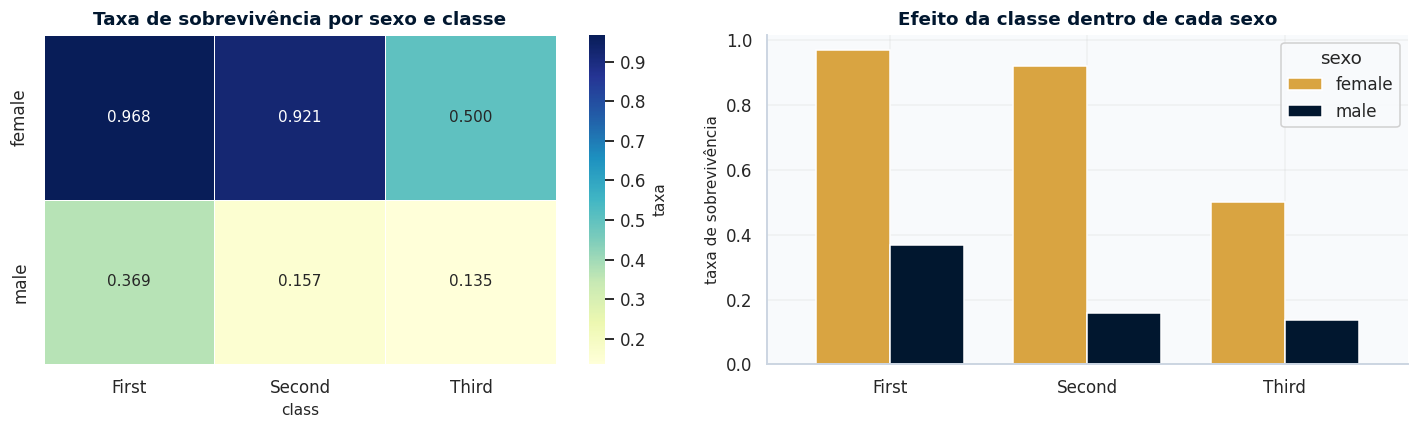

In [15]:
# @title ▶️ 10.1 Interação entre sexo e classe
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(taxa, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax[0],
            linewidths=.5, linecolor="white", cbar_kws={"label": "taxa"})
ax[0].set_title("Taxa de sobrevivência por sexo e classe"); ax[0].set_ylabel("")

taxa.T.plot(kind="bar", ax=ax[1], color=[nu.PALETA["gold"], nu.PALETA["navy"]],
            edgecolor="white", width=.75)
ax[1].set_title("Efeito da classe dentro de cada sexo")
ax[1].set_ylabel("taxa de sobrevivência"); ax[1].set_xlabel("")
ax[1].tick_params(axis="x", rotation=0); ax[1].legend(title="sexo")

plt.tight_layout(); plt.show()

> ✅ **Leitura principal**
>
> O efeito da classe **não é uniforme entre os sexos**, e as duas
> medidas apontam em direções opostas:

| | 1ª classe | 3ª classe | amplitude | razão |
|---|---|---|---|---|
| feminino | 0,968 | 0,500 | **0,468** | 1,94× |
| masculino | 0,369 | 0,135 | 0,233 | **2,72×** |

Em **diferença absoluta**, o efeito da classe é maior entre mulheres (46,8 p.p. contra
23,3 p.p.). Em **efeito relativo**, é maior entre homens (2,72× contra 1,94×).

Nenhuma das duas leituras é "a correta" — elas respondem a perguntas distintas. A
amplitude responde "quantas vidas a mais, proporcionalmente à população do grupo"; a
razão responde "quantas vezes maior a chance". Reportar apenas uma delas seleciona a
conclusão pela métrica.

O que ambas confirmam é a **interação**: não são dois efeitos aditivos independentes. O
material de referência apresenta sexo e classe como fatores separados ordenados por
importância — simplificação que a tabela contradiz, porque a magnitude do efeito de cada
um depende do nível do outro.

O suporte é exibido junto porque a menor célula tem 76 observações. Taxa sem denominador
não é auditável.

### 10.2 Agregações múltiplas e descritivas por grupo

> 🎯 **Pergunta:** Caracterizar tarifa e idade por classe com estatísticas múltiplas em uma passagem.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

`groupby` com `agg` de múltiplas funções, e `describe` por grupo. Todas as medidas de dispersão usam `ddof=1` e todos os quantis usam interpolação linear, conforme a Seção 3.

</details>

In [16]:
# @title ▶️ 10.2 Agregações múltiplas e descritivas por grupo
resumo = trab.groupby("class", observed=True).agg(
    n=("survived", "size"),
    taxa_sobrev=("survived", "mean"),
    tarifa_mediana=("fare", "median"),
    tarifa_media=("fare", "mean"),
    tarifa_desvio=("fare", nu.desvio),
    idade_mediana=("age", "median"))
display(resumo.round(4))

print("Descritivas de fare por classe:")
display(trab.groupby("class", observed=True)["fare"].describe().round(3))

print("Agregação por duas chaves (sexo × acompanhado):")
display(trab.groupby(["sex", "acompanhado"], observed=True)["survived"]
          .agg(["size", "mean"]).round(4))

,n,taxa_sobrev,tarifa_mediana,tarifa_media,tarifa_desvio,idade_mediana
class,,,,,,
First,216,0.6296,60.2875,84.1547,78.3804,37.0
Second,184,0.4728,14.2500,20.6622,13.4174,29.0
Third,491,0.2424,8.0500,13.6756,11.7781,24.0


Descritivas de fare por classe:


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
First,216.0,84.155,78.380,0.0,30.924,60.287,93.5,512.329
Second,184.0,20.662,13.417,0.0,13.000,14.250,26.0,73.500
Third,491.0,13.676,11.778,0.0,7.750,8.050,15.5,69.550


Agregação por duas chaves (sexo × acompanhado):


size    mean
sex    acompanhado              
female Não           126  0.7857
       Sim           188  0.7128
male   Não           411  0.1557
       Sim           166  0.2711

> ✅ **Leitura principal**
>
> A tarifa mediana é consistentemente inferior à média em todas as
> classes, indicando assimetria à direita — poucas tarifas muito altas puxam a média. Para
> variável assim, mediana e IQR descrevem o comportamento típico melhor que média e desvio.

O cruzamento por `acompanhado` mostra que viajar acompanhado se associa a maior
sobrevivência em ambos os sexos, mas a diferença entre sexos permanece muito superior à
diferença entre acompanhados e desacompanhados. A coluna derivada na Seção 6.1 é
informativa, porém secundária.

### 10.3 Distribuição conjunta por faixa etária

> 🎯 **Pergunta:** Verificar se a faixa etária derivada carrega informação além da já contida em sexo.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Tabulação cruzada de faixa etária por desfecho e tabela dinâmica de taxa por faixa e sexo. Os `NaN` de idade são mantidos visíveis para que a leitura considere quanto da amostra fica fora da tabela.

</details>

In [17]:
# @title ▶️ 10.3 Distribuição conjunta por faixa etária
cruz = pd.crosstab(trab["faixa_etaria"], trab["survived"], margins=True)
print("Contagem por faixa etária e desfecho:"); display(cruz)

taxa_faixa = trab.pivot_table(values="survived", index="faixa_etaria",
                              columns="sex", aggfunc="mean", observed=True)
display(taxa_faixa.round(4))

cobertura = trab["faixa_etaria"].notna().mean()
print(f"Cobertura da tabela: {cobertura:.2%} da amostra "
      f"({int(trab['faixa_etaria'].isna().sum())} registros sem idade ficam fora)")

Contagem por faixa etária e desfecho:


survived,0,1,All
faixa_etaria,,,
0–12,29,40,69
13–25,148,84,232
26–60,230,161,391
61+,17,5,22
All,424,290,714


sex,female,male
faixa_etaria,,
0–12,0.5938,0.5676
13–25,0.7556,0.1127
26–60,0.7868,0.2118
61+,1.0000,0.1053


Cobertura da tabela: 80.13% da amostra (177 registros sem idade ficam fora)


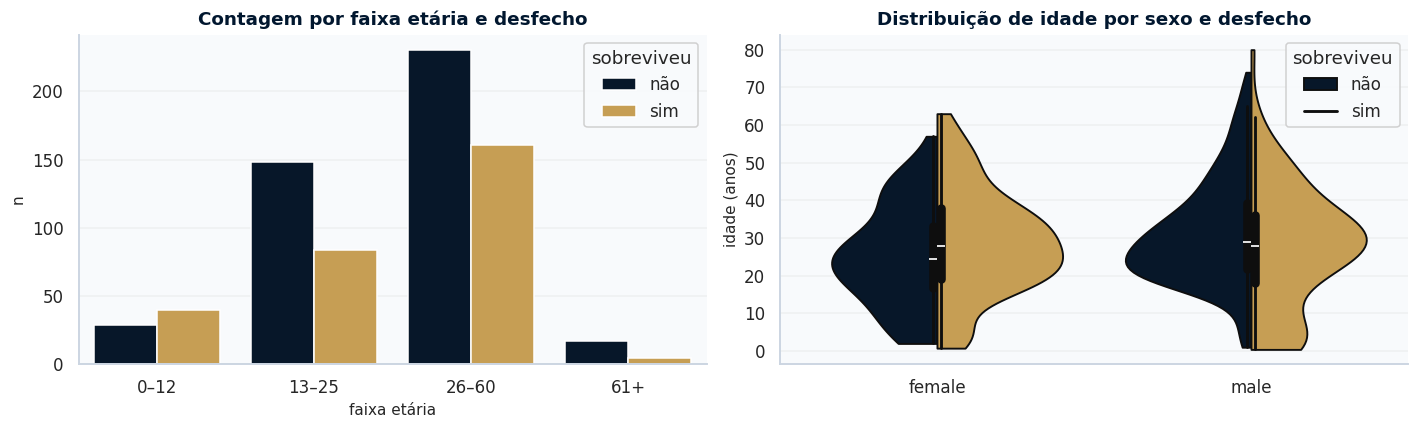

In [18]:
# @title ▶️ 10.3 Distribuição conjunta por faixa etária
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=trab, x="faixa_etaria", hue="survived", ax=ax[0],
              palette=[nu.PALETA["navy"], nu.PALETA["gold"]])
ax[0].set_title("Contagem por faixa etária e desfecho")
ax[0].set_xlabel("faixa etária"); ax[0].set_ylabel("n")
ax[0].legend(title="sobreviveu", labels=["não", "sim"])

sns.violinplot(data=trab, x="sex", y="age", hue="survived", split=True, ax=ax[1],
               palette=[nu.PALETA["navy"], nu.PALETA["gold"]], cut=0)
ax[1].set_title("Distribuição de idade por sexo e desfecho")
ax[1].set_xlabel(""); ax[1].set_ylabel("idade (anos)")
ax[1].legend(title="sobreviveu", labels=["não", "sim"])

plt.tight_layout(); plt.show()

> ✅ **Leitura principal**
>
> A faixa `0–12` apresenta taxa de sobrevivência superior às demais
> em ambos os sexos, consistente com prioridade a crianças. Nas faixas adultas, a diferença
> entre sexos supera amplamente a diferença entre faixas.

⚠️ **Limite:** a tabela cobre 80,13% da amostra. Os 177 registros sem idade
ficam fora, e a Seção 7 mostrou que essa ausência não é aleatória. Conclusões sobre idade
carregam essa limitação. O parâmetro `cut=0` no diagrama de violino evita que a
estimativa de densidade extrapole e sugira idade negativa.

---

## 💾 11. Registro dos achados

Cada entrega grava um arquivo JSON com seus resultados e as convenções empregadas. A síntese da Entrega 1.3 lê esses arquivos em vez de recalcular, garantindo que os números do relatório final sejam idênticos aos dos notebooks.

In [19]:
# @title ▶️ 💾 11. Registro dos achados
achados = {
    "entrega": "1.1",
    "dataset": "Titanic (seaborn-data)",
    "md5": integridade["md5"],
    "linhas": int(len(df)), "colunas": int(df.shape[1]),
    "calibracao": "OK",
    "duplicatas_linha_inteira": dup_total,
    "duplicatas_chave_parcial": dup_chave,
    "vazamento": suspeitos,
    "age_ausentes_pct": round(100 * bruta.isna().mean(), 2),
    "reducao_dispersao_por_imputacao_pct": round(100 * (1 - razao_obs), 2),
    "fator_teorico_confirmado": bool(abs(razao_obs - fator_teorico) < 1e-9),
    "outliers_setosa_tipo7": int(setosa[setosa["definição"] == "tipo 7"]["outliers"].iloc[0]),
    "outliers_setosa_tipo1": int(setosa[setosa["definição"] == "tipo 1"]["outliers"].iloc[0]),
    "simpson_agregado": round(float(pooled), 4),
    "simpson_por_especie": [round(float(v), 4) for v in por_especie],
    "amplitude_classe_por_sexo": {k: float(v) for k, v in amplitude.items()},
    "razao_classe_por_sexo": {k: float(v) for k, v in razao.items()},
    "cobertura_faixa_etaria_pct": round(100 * float(cobertura), 2),
    "convencoes": nu.CONVENCOES,
}
json.dump(achados, open("resultados/entrega_1_1.json", "w"), indent=2, ensure_ascii=False)
print(json.dumps(achados, indent=2, ensure_ascii=False))

{
  "entrega": "1.1",
  "dataset": "Titanic (seaborn-data)",
  "md5": "56f29cc0b807",
  "linhas": 891,
  "colunas": 15,
  "calibracao": "OK",
  "duplicatas_linha_inteira": 107,
  "duplicatas_chave_parcial": 137,
  "vazamento": [
    "alive"
  ],
  "age_ausentes_pct": 19.87,
  "reducao_dispersao_por_imputacao_pct": 10.49,
  "fator_teorico_confirmado": true,
  "outliers_setosa_tipo7": 4,
  "outliers_setosa_tipo1": 1,
  "simpson_agregado": -0.1176,
  "simpson_por_especie": [
    0.7425,
    0.5259,
    0.4572
  ],
  "amplitude_classe_por_sexo": {
    "female": 0.4681,
    "male": 0.2334
  },
  "razao_classe_por_sexo": {
    "female": 1.936,
    "male": 2.723
  },
  "cobertura_faixa_etaria_pct": 80.13,
  "convencoes": {
    "quantil": "linear",
    "ddof": 1,
    "outlier": "1.5*IQR",
    "corr": "pearson"
  }
}


---

## 🚀 12. Conclusões e recomendações

### 12.1 Estado do pipeline

Calibrado. Seis de seis agregados conferem com os valores conhecidos e `age` apresenta
exatamente 177 ausências. As Entregas 1.2 e 1.3 herdam estas convenções.

### 12.2 Modos de falha quantificados

| # | Modo de falha | Evidência | Efeito sobre a conclusão |
|---|---|---|---|
| I | Imputação anterior à análise | dispersão de `age` contrai **10,49%**, coincidente com $\sqrt{(m-1)/(n-1)}$ | associação com o desfecho é atenuada |
| II | Convenção de quantil | setosa: **4** outliers (tipo 7) contra **1** (tipo 1) | critério de exclusão muda sem aviso |
| III | Agregação sobre grupos heterogêneos | $r = -0{,}118$ agregado contra $+0{,}74$, $+0{,}53$, $+0{,}46$ por espécie | sinal da relação se inverte |

Os três compartilham uma característica: **não produzem erro, aviso nem valor
visivelmente anômalo**. Todos alteram a conclusão.

### 12.3 Achados substantivos

**Interação entre sexo e classe.** O efeito da classe **não é aditivo em relação ao
sexo**, e a direção depende da métrica: em diferença absoluta o efeito é maior entre
mulheres (46,8 p.p. contra 23,3 p.p.); em razão, maior entre homens (2,72× contra
1,94×). Apresentar sexo e classe como fatores independentes ordenados por importância
descreve mal o fenômeno.

**Duplicatas legítimas.** As 107 duplicatas de linha inteira não são erro de dados: 125
dos 160 registros envolvidos são da terceira classe e 58,1% têm idade ausente.
`drop_duplicates`, previsto como etapa padrão no material de referência, eliminaria
pessoas reais e reduziria a representação justamente do grupo de menor sobrevivência.

### 12.4 Recomendações

1. **Declarar as convenções** (`ddof`, definição de quantil, regra de outlier) no corpo
   do relatório, não apenas no código.
2. **Automatizar o rastreio de vazamento.** Inspeção visual de nomes de coluna não
   escala além de poucas dezenas de variáveis.
3. **Não imputar e analisar a mesma variável** sem marcação da imputação.
4. **Verificar correlação intragrupo** antes de reportar correlação agregada.
5. **Exibir suporte junto de taxa.** Proporção sem $n$ não é auditável.
6. **Reportar diferença absoluta e razão** ao comparar proporções entre grupos. Uma só
   das duas permite selecionar a conclusão pela métrica.
7. **Caracterizar duplicatas antes de removê-las.** `drop_duplicates` sobre chave não
   identificadora elimina entidades distintas.

### 12.5 Continuidade

A Entrega 1.2 aplica esta mesma auditoria a um conjunto de dados de segurança IoT. O
resultado obriga a reformular a pergunta de pesquisa daquela entrega.

---

## 💾 Apêndice A — Registro de decisões

Decisões metodológicas tomadas nesta entrega, com a alternativa descartada e a
justificativa. Serve para que a revisão questione a escolha, não a omissão.

| Decisão | Alternativa descartada | Justificativa |
|---|---|---|
| Usar `seaborn-data` em vez do `train.csv` do Kaggle | dataset da competição | os valores de calibração são específicos deste esquema; a troca exigiria recalibrar |
| Manter as 107 duplicatas de linha inteira | `drop_duplicates()` | 125 dos 160 registros são da 3ª classe e 58% têm idade ausente: são passageiros distintos coincidentes, não repetição. Remover enviesaria contra o grupo de menor sobrevivência |
| Reportar amplitude e razão na interação | somente a amplitude | as duas medidas apontam sexos diferentes; publicar uma só permitiria escolher a conclusão |
| Borda inferior do `pd.cut` em `-0.01` | `bins=[0, 12, ...]` | com `right=True` o primeiro intervalo seria `(0, 12]` e idades abaixo de 1 ano seriam descartadas |
| Manter `NaN` em `faixa_etaria` | imputar antes de categorizar | a Seção 7 demonstra que a imputação contrai a dispersão e enviesa a comparação entre classes |
| `cut=0` no diagrama de violino | parâmetro padrão | a estimativa de densidade padrão extrapola além do suporte e sugeriria idade negativa |
| Exibir suporte junto das taxas | somente a tabela de taxas | a menor célula tem n=76; taxa sem denominador não é auditável |


---

## 🧰 Apêndice B — Referência rápida

**Auditoria de entrada**

```python
nu.integridade('arquivo.csv', df)      # md5 + wc -l contra parser
nu.perfil(df)                          # nulos, vazios_str, únicos, constantes
df.duplicated().sum()                  # linha inteira
df.duplicated(subset=chave).sum()      # chave parcial
nu.suspeitos_de_vazamento(df, 'alvo')
```

**Estatística com convenção declarada**

```python
nu.CONVENCOES                          # {'quantil': 'linear', 'ddof': 1, ...}
nu.quantis(s)                          # uma passagem, não três
nu.desvio(s)                           # ddof=1 explícito
nu.outliers(s)                         # máscara booleana, regra de Tukey
nu.correlacoes(df, por='grupo')        # evita agregação heterogênea
```

**Limpeza e derivação**

```python
df.drop(columns=[...])
s.astype(str).str.strip().str.title()
pd.cut(s, bins=[-0.01, 12, 25, 60, 120], labels=[...])   # borda explícita
np.where(cond, 'Sim', 'Não')           # avalia AMBOS os ramos
```

**Agregação e cruzamento**

```python
df.pivot_table(values=, index=, columns=, aggfunc=, observed=True)
df.groupby(k, observed=True).agg(n=('c','size'), taxa=('c','mean'))
df.groupby(k, observed=True)['c'].describe()
pd.crosstab(a, b, margins=True)
```